In [1]:
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('../data', exist_ok=True)
os.makedirs('../output', exist_ok=True)
os.makedirs('../visualizations', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
ARFF_PATH = '../data/OVA_Breast.arff'

data, meta = arff.loadarff(ARFF_PATH)
df_raw = pd.DataFrame(data)

# Kategoricke/string kolone se u scipy.io.arff ucitavaju kao bytes objekti - dekodiramo ih
df_raw['Tissue'] = df_raw['Tissue'].str.decode('utf-8')

print(f"Oblik podataka: {df_raw.shape}")
print(f"Kolone (prvih 5): {df_raw.columns[:5].tolist()}")
print(f"Kolone (poslednje 3): {df_raw.columns[-3:].tolist()}")

Oblik podataka: (1545, 10937)
Kolone (prvih 5): ['ID_REF', '1007_s_at', '121_at', '1405_i_at', '1438_at']
Kolone (poslednje 3): ['AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'Tissue']


In [3]:
print("=== Osnovne informacije ===")
print(f"Broj instanci: {df_raw.shape[0]}")
print(f"Broj atributa (ukupno, sa ID_REF i Tissue): {df_raw.shape[1]}")
print(f"Broj gen-ekspresija atributa: {df_raw.shape[1] - 2}")
print()
print("=== Raspodela ciljnog atributa Tissue ===")
print(df_raw['Tissue'].value_counts())
print()
print(df_raw['Tissue'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== Osnovne informacije ===
Broj instanci: 1545
Broj atributa (ukupno, sa ID_REF i Tissue): 10937
Broj gen-ekspresija atributa: 10935

=== Raspodela ciljnog atributa Tissue ===
Tissue
Other     1201
Breast     344
Name: count, dtype: int64

Tissue
Other     77.7%
Breast    22.3%
Name: proportion, dtype: object


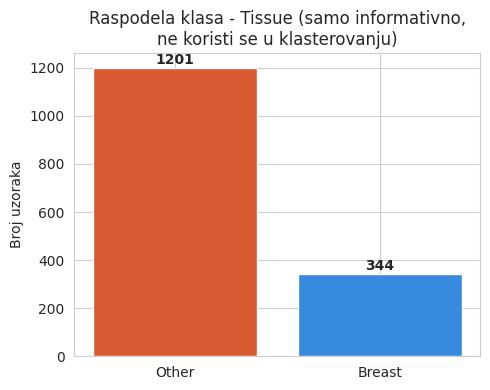


Napomena: klase su neuravnotezene (1201 vs 344, odnos ~3.5:1). Ovo je bitno pri tumacenju eksterne evaluacije klastera - klasteri se ne moraju poklapati 1:1 sa ovom podelom.


In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df_raw['Tissue'].value_counts()
colors = ['#D85A30', '#378ADD']
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel('Broj uzoraka')
ax.set_title('Raspodela klasa - Tissue (samo informativno,\nne koristi se u klasterovanju)')
for i, v in enumerate(counts.values):
    ax.text(i, v + 15, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/class_distribution.png', dpi=150)
plt.show()

print(f"\nNapomena: klase su neuravnotezene ({counts.iloc[0]} vs {counts.iloc[1]}, "
      f"odnos ~{counts.iloc[0]/counts.iloc[1]:.1f}:1). Ovo je bitno pri tumacenju "
      f"eksterne evaluacije klastera - klasteri se ne moraju poklapati 1:1 sa ovom podelom.")

In [5]:
missing = df_raw.isnull().sum().sum()
print(f"Ukupan broj nedostajucih vrednosti: {missing}")

dup_ids = df_raw['ID_REF'].duplicated().sum()
print(f"Broj dupliranih ID_REF vrednosti: {dup_ids}")

dup_rows = df_raw.drop(columns=['ID_REF']).duplicated().sum()
print(f"Broj potpuno dupliranih redova (bez ID_REF): {dup_rows}")

sample_cols = df_raw.drop(columns=['ID_REF', 'Tissue']).sample(5, axis=1, random_state=RANDOM_STATE).columns
print("\nRaspon vrednosti za 5 nasumicno izabranih gena (ilustracija heterogenosti):")
print(df_raw[sample_cols].describe().loc[['min', 'mean', 'max']].T)


Ukupan broj nedostajucih vrednosti: 0
Broj dupliranih ID_REF vrednosti: 0
Broj potpuno dupliranih redova (bez ID_REF): 0

Raspon vrednosti za 5 nasumicno izabranih gena (ilustracija heterogenosti):
               min         mean      max
200726_at    247.2  8639.217799  20272.3
205649_s_at    0.7   147.766278  40890.0
201199_s_at  143.6  2735.600906  10224.4
214175_x_at    6.8   560.829644   7609.0
227462_at      3.5   792.036505   5058.2


In [6]:
y_tissue = df_raw['Tissue'].copy()
X_raw = df_raw.drop(columns=['ID_REF', 'Tissue'])

print(f"Oblik matrice atributa (X): {X_raw.shape}")
print(f"Oblik labele (y, samo za evaluaciju): {y_tissue.shape}")


Oblik matrice atributa (X): (1545, 10935)
Oblik labele (y, samo za evaluaciju): (1545,)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns, index=X_raw.index)

print("Standardizacija zavrsena.")
print(f"Prosek po koloni posle skaliranja (treba biti ~0): {X_scaled.values.mean():.6f}")
print(f"Std po koloni posle skaliranja (treba biti ~1): {X_scaled.values.std():.6f}")

Standardizacija zavrsena.
Prosek po koloni posle skaliranja (treba biti ~0): 0.000000
Std po koloni posle skaliranja (treba biti ~1): 1.000000


In [8]:
df_preprocessed = X_scaled.copy()
df_preprocessed['Tissue'] = y_tissue.values

df_preprocessed.to_pickle('../data/data_preprocessed_full.pkl')
size_mb = os.path.getsize('../data/data_preprocessed_full.pkl') / (1024**2)
print(f"Sacuvano: data/data_preprocessed_full.pkl, oblik: {df_preprocessed.shape}, velicina: {size_mb:.1f} MB")

Sacuvano: data/data_preprocessed_full.pkl, oblik: (1545, 10936), velicina: 129.0 MB


In [ ]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

for target in [0.5, 0.7, 0.9, 0.95]:
    n_comp = np.argmax(cumvar >= target) + 1
    print(f"{target*100:.0f}% objasnjene varijanse -> potrebno {n_comp} komponenti")


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, color='#0F6E56')
ax.axhline(0.9, color='#993C1D', linestyle='--', linewidth=1, label='90% varijanse')
ax.set_xlabel('Broj glavnih komponenti')
ax.set_ylabel('Kumulativna objasnjena varijansa')
ax.set_title('PCA - kumulativna objasnjena varijansa')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/pca_explained_variance.png', dpi=150)
plt.show()

In [ ]:
N_COMPONENTS = 50
pca_50 = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca50 = pca_50.fit_transform(X_scaled)

print(f"PCA (50 komponenti) oblik: {X_pca50.shape}")
print(f"Objasnjena varijansa: {pca_50.explained_variance_ratio_.sum()*100:.2f}%")

df_pca50 = pd.DataFrame(X_pca50, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])
df_pca50['Tissue'] = y_tissue.values
df_pca50.to_csv('../data/data_preprocessed_pca50.csv', index=False)
print("Sacuvano: data/data_preprocessed_pca50.csv")


In [ ]:
TOP_K = 200
variances = X_scaled.var(axis=0)
top_genes = variances.sort_values(ascending=False).head(TOP_K).index

X_topvar = X_scaled[top_genes]
print(f"Skup top-{TOP_K} najvarijabilnijih gena, oblik: {X_topvar.shape}")

df_topvar = X_topvar.copy()
df_topvar['Tissue'] = y_tissue.values
df_topvar.to_csv('../data/data_preprocessed_topvar200.csv', index=False)
print(f"Sacuvano: data/data_preprocessed_topvar200.csv")


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3.fit_transform(X_scaled)

colors_map = {'Breast': '#D85A30', 'Other': '#378ADD'}

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(1, 2, 1)
for label, color in colors_map.items():
    mask = (y_tissue == label).values
    ax1.scatter(X_pca3[mask, 0], X_pca3[mask, 1], c=color, label=label, alpha=0.6, s=15)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('2D PCA projekcija (obojeno po Tissue)')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for label, color in colors_map.items():
    mask = (y_tissue == label).values
    ax2.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2], c=color, label=label, alpha=0.6, s=15)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('3D PCA projekcija (obojeno po Tissue)')
ax2.legend()

plt.tight_layout()
plt.savefig('../visualizations/pca_2d_3d.png', dpi=150)
plt.show()

In [ ]:
with open('../output/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../output/pca_50.pkl', 'wb') as f:
    pickle.dump(pca_50, f)
with open('../output/top_var_genes.pkl', 'wb') as f:
    pickle.dump(list(top_genes), f)

print("Sacuvani pomocni objekti: scaler.pkl, pca_50.pkl, top_var_genes.pkl")
print("\nDAN 1 zavrsen. Spremno za Dan 2 - klasterovanje.")
